LOGIC:
1. Group songs by release month
2. Calculate average and standard deviation for each month
3. Flag songs with views > 2 standard deviations above monthly average
4. These are "anomalies" worth studying

In [101]:
# Load Libraries
import pandas as pd
import matplotlib.pyplot as plt
from datetime import datetime, timedelta
import seaborn as sns
import numpy as np

# Load Data
df_songs = pd.read_csv("C:/fiifi/Shatta_Analytics_Project/Python_files/python_data_analysis/songs_fact.csv", index_col=0)
df_metrics = pd.read_csv("C:/fiifi/Shatta_Analytics_Project/Python_files/python_data_analysis/platform_metrics_dim.csv", index_col=0)

In [102]:
# Clean Data
# Filter for youtube only
df_youtube = df_metrics[df_metrics["platform_name"] == "YouTube"].copy()

# Merge df_youtube & df_songs
df_merged = df_songs.merge(right=df_youtube, how="inner", on="song_id")

# Drop release_date_original and release_date_original.1
df_merged = df_merged.drop(columns=["release_date_original", "release_date_original.1"])

# Convert release_date  to datetime
df_merged["release_date"] = pd.to_datetime(df_merged["release_date"], dayfirst=False, errors="coerce")

# Calculate song age in days (to filter for only mature songs)
reference_date = datetime.now()
df_merged["age_days"] = (reference_date - df_merged["release_date"]).dt.days

# remove songs with invalid dates or negative age
df_merged = df_merged[df_merged["age_days"] >= 0].copy()

# Get only mature songs (songs older than 90 days)
df_mature = df_merged[df_merged["age_days"] >= 90].copy()

In [103]:
# Create a year-month column for grouping ("2024-03")
df_mature["year_month"] = df_mature["release_date"].dt.strftime("%Y-%m")

# Get month for display
df_mature["month_name"] = df_mature["release_date"].dt.strftime("%B %Y")

In [104]:
# Calculate Monthly Stats
monthly_stats = df_mature.groupby("year_month").agg({"views": ["mean", "std", "count", "min", "max"]}).round(0)
# monthly_stats = df_mature.groupby("year_month")["views"].agg(["mean", "std"]).round(0)

# Rename columns for easy access
monthly_stats.columns= ["monthly_avg", "monthly_std", "song_count", "monthly_min", "monthly_max"]

# Calculate upper threshold (mean + (2 * standard deviation))
monthly_stats["upper_threshold"] = monthly_stats["monthly_avg"] + (2 * monthly_stats["monthly_std"])

# Add month name for display
monthly_stats["month_name"] = df_mature.groupby("year_month")["release_date"].first().dt.strftime("%B %Y")

In [105]:
# Identify Anlomalies
# Merge monthly stats back to each song
df_mature = df_mature.merge(
    monthly_stats[["monthly_avg", "monthly_std", "upper_threshold"]], 
    left_on="year_month", 
    right_index=True
)

# Calculate z-score (how many standard deviations above/ below average)
df_mature["z_score"] = (df_mature["views"] - df_mature["monthly_avg"]) / (df_mature["monthly_std"])

In [106]:
# Flag anomalies (songs with views > 2 standard deviations above monthly average)
df_mature["is_anomaly"] = df_mature["views"] > df_mature["upper_threshold"]

# Calculate how much above average (percentage)
df_mature["pct_above_avg"] = ((df_mature["views"] - df_mature["monthly_avg"]) / df_mature["monthly_avg"]) * 100

In [107]:
# Extract anomaly songs
anomalies = df_mature[df_mature["is_anomaly"] == True].copy()
anomalies = anomalies.sort_values("z_score", ascending=False)

# Display top anomalies
# Prepare display columns
display_cols = ["title", "release_date", "month_name", "views", "monthly_avg", "z_score", "pct_above_avg"]

top_anomalies = anomalies.head(10)[display_cols].copy()
top_anomalies["views"] = top_anomalies["views"].apply(lambda x: f"{x:,.0f}")
top_anomalies["monthly_avg"] = top_anomalies["monthly_avg"].apply(lambda x: f"{x:,.0f}")
top_anomalies["pct_above_avg"] = top_anomalies["pct_above_avg"].round(1).astype(str) + "%"
top_anomalies.columns = ["Song Title", "Release_date", "Month", "Views", "Monthly_Avg", "Z-Score", "Above Avg %"]

In [108]:
top_anomalies.sample(10)

,Song Title,Release_date,Month,Views,Monthly_Avg,Z-Score,Above Avg %
568,Star Boy (Viral Video),2017-11-01,November 2017,"1,936,061","182,847",3.721959,958.8%
849,Bandana - Moko Hoo Ft. Tinny (Official Video),2016-01-06,January 2016,"726,492","109,955",3.582060,560.7%
727,Shatta Wale Ft. Davido - Wine Your Waist (Audi...,2016-11-14,November 2016,"420,670","35,541",5.779333,1083.6%
805,Prove You Wrong (Official Video),2016-09-13,September 2016,"2,006,721","146,822",4.560331,1266.8%
744,Cocoa Season (Official Video),2016-10-26,October 2016,"969,798","55,099",6.066408,1660.1%
70,Playboy (Official Video),2025-11-01,November 2025,"992,573","132,342",3.694040,650.0%
476,Only One Man (Audio Slide),2019-03-05,March 2019,"1,299,178","198,255",3.120433,555.3%
684,Mechanism (Official Video),2016-12-11,December 2016,"637,405","74,180",3.412244,759.3%
164,Minamino Sin (Visualizer),2024-01-23,January 2024,"1,137,817","201,852",4.001441,463.7%
581,Freedom (Audio Slide),2017-10-08,October 2017,"2,001,190","194,134",3.840249,930.8%


In [ ]:
# Negative anomalies (Underperformers)
# Songs performing significantly WORSE than monthly average
lower_threshold = monthly_stats["monthly_avg"] - (2 * monthly_stats["monthly_std"])
df_mature["lower_threshold"] = df_mature["year_month"].map(monthly_stats["monthly_avg"] - (2 * monthly_stats["monthly_std"]))
df_mature["is_negative_anomaly"] = df_mature["views"] < df_mature["lower_threshold"]

underperformers = df_mature[df_mature["is_negative_anomaly"] == True].copy()
underperformers = underperformers.sort_values("z_score", ascending=True)

top_underperformers = underperformers.head(10)[display_cols].copy()
top_underperformers['views'] = top_underperformers['views'].apply(lambda x: f"{x:,.0f}")
top_underperformers['monthly_avg'] = top_underperformers['monthly_avg'].apply(lambda x: f"{x:,.0f}")
top_underperformers['pct_above_avg'] = top_underperformers['pct_above_avg'].round(1).astype(str) + '%'
top_underperformers.columns = ['Song Title', 'Release Date', 'Month', 'Views', 'Month Avg', 'Z-Score', 'vs Avg %']

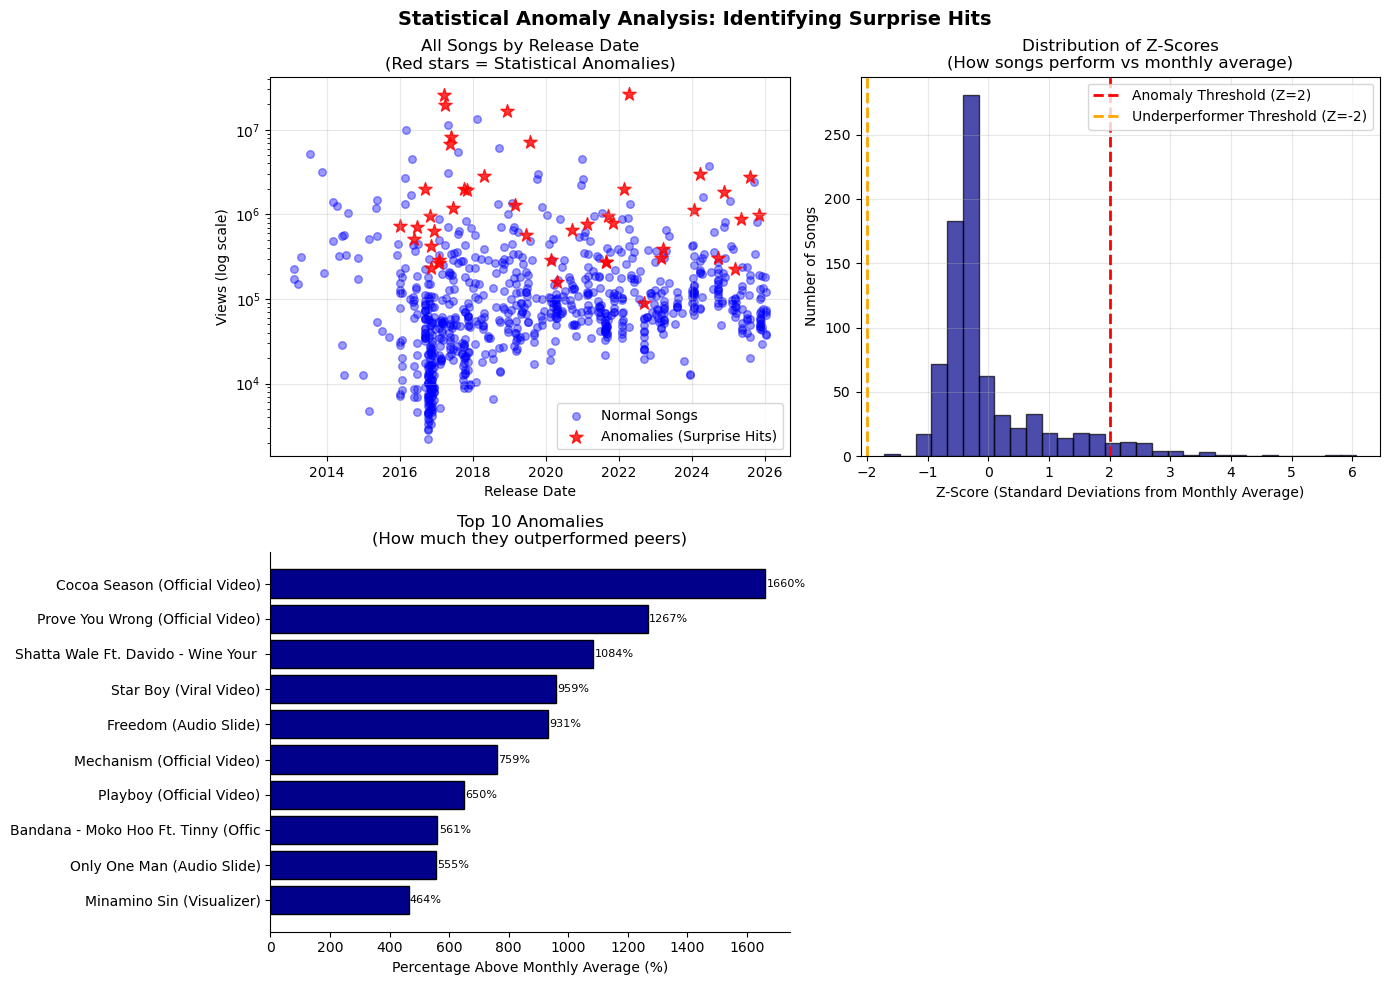

In [133]:
# Visualization
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# Hide the 4th subplot (bottom right)
axes[1, 1].set_visible(False)

fig.suptitle('Statistical Anomaly Analysis: Identifying Surprise Hits', fontsize=14, fontweight='bold')

# Plot 1: Scatter plot of all songs colored by anomaly status
ax1 = axes[0, 0]

# Plot normal songs
normal = df_mature[~df_mature['is_anomaly']]
ax1.scatter(normal['release_date'], normal['views'], alpha=0.4, s=30, c='blue', label='Normal Songs')

# Plot anomalies
if len(anomalies) > 0:
    ax1.scatter(anomalies['release_date'], anomalies['views'], alpha=0.8, s=100, c='red', marker='*', label='Anomalies (Surprise Hits)')

ax1.set_xlabel('Release Date')
ax1.set_ylabel('Views (log scale)')
ax1.set_title('All Songs by Release Date\n(Red stars = Statistical Anomalies)')
ax1.set_yscale('log')
ax1.legend()
ax1.grid(True, alpha=0.3)

# Plot 2: Z-Score distribution (histogram)
ax2 = axes[0, 1]
ax2.hist(df_mature['z_score'], bins=30, color='darkblue', edgecolor='black', alpha=0.7)
ax2.axvline(x=2, color='red', linestyle='--', linewidth=2, label='Anomaly Threshold (Z=2)')
ax2.axvline(x=-2, color='orange', linestyle='--', linewidth=2, label='Underperformer Threshold (Z=-2)')
ax2.set_xlabel('Z-Score (Standard Deviations from Monthly Average)')
ax2.set_ylabel('Number of Songs')
ax2.set_title('Distribution of Z-Scores\n(How songs perform vs monthly average)')
ax2.legend()
ax2.grid(True, alpha=0.3)

# Plot 3: Top 10 Anomalies - Horizontal Bar Chart
ax3 = axes[1, 0]
if len(anomalies) > 0:
    top_anom = anomalies.head(10).copy()
    top_anom = top_anom.sort_values('pct_above_avg', ascending=True)
    
    bars = ax3.barh(range(len(top_anom)), top_anom['pct_above_avg'], color='darkblue', edgecolor='black')
    ax3.set_yticks(range(len(top_anom)))
    ax3.set_yticklabels(top_anom['title'].str[:35])
    ax3.set_xlabel('Percentage Above Monthly Average (%)')
    ax3.set_title('Top 10 Anomalies\n(How much they outperformed peers)')
    ax3.spines['right'].set_visible(False) # despine
    ax3.spines['top'].set_visible(False)

    for bar, val in zip(bars, top_anom['pct_above_avg']):
        ax3.text(val + 5, bar.get_y() + bar.get_height()/2, f'{val:.0f}%', va='center', fontsize=8)
else:
    ax3.text(0.5, 0.5, 'No anomalies found', ha='center', va='center', transform=ax3.transAxes)
    ax3.set_title('Top 10 Anomalies')

plt.tight_layout()
plt.show()

Insights:
- Cocoa Season is the biggest statistical outlier in the catalog – At 1,660% above monthly average, this song dramatically outperformed every other song released in its same month by a massive margin
- The top 3 anomalies all exceeded 1,000% above average – Cocoa Season (1,660%), Prove You Wrong (1,267%), and Wine Your Waist (1,084%) represent completely unexpected breakout hits
- Most anomalies are older songs (2014-2017) – This suggests these songs may have benefited from unique circumstances (viral moments, playlist placements, or cultural events) rather than just standard promotion

Recommendations
- Investigate what made Cocoa Season explode – Analyze comments, external mentions, and timing to understand the specific driver (Was it a dance challenge? Radio play? Feature placement?) then replicate that strategy
- Study the common elements among top anomalies – Look for patterns in genre, producers, collaborators, or release timing that might explain their unexpected success
- Re-promote these anomaly songs – They have already proven they resonate with audiences; a remix, video upgrade, or social media push could generate additional momentum